In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
# importing data
df = pd.read_csv('../datasets/ds_challenge_v2_1_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (54681, 11)


,id,city_name,signup_os,signup_channel,signup_date,bgc_date,vehicle_added_date,vehicle_make,vehicle_model,vehicle_year,first_completed_date
0,1,Strark,ios web,Paid,1/2/16,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Strark,windows,Paid,1/21/16,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Wrouver,windows,Organic,1/11/16,1/11/16,NaN,NaN,NaN,NaN,NaN
3,4,Berton,android web,Referral,1/29/16,2/3/16,2/3/16,Toyota,Corolla,2016.0,2/3/16
4,5,Strark,android web,Referral,1/10/16,1/25/16,1/26/16,Hyundai,Sonata,2016.0,NaN


In [3]:
# adjust datatypes
df['vehicle_year'] = df['vehicle_year'].astype('float64')
date_cols = ['signup_date','first_completed_date','bgc_date', 'vehicle_added_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format = '%m/%d/%y')

df['Is Driver'] = ~ pd.isna(df['first_completed_date'])

In [4]:
# time between metrics
df['signup_to_bgc'] = (df['bgc_date'] - df['signup_date']) / datetime.timedelta(days = 1)
df['signup_to_vehicle_added'] = (df['vehicle_added_date'] - df['signup_date'])/datetime.timedelta(days = 1)
df['signup_to_first_completed'] = (df['first_completed_date'] - df['signup_date'])/datetime.timedelta(days = 1)
df['bgc_to_vehicle_added'] = (df['vehicle_added_date'] - df['bgc_date'])/datetime.timedelta(days = 1)
df['bgc_to_first_completed'] = (df['first_completed_date'] - df['bgc_date'])/datetime.timedelta(days = 1)
df['vehicle_added_to_first_completed'] = (df['first_completed_date'] - df['vehicle_added_date'])/datetime.timedelta(days = 1)


# snapshot date
snap_date = pd.to_datetime('4/1/16',format = '%m/%d/%y')
# days since difference metrics
df['days_since_signup'] = (snap_date - df['signup_date'])/datetime.timedelta(days = 1)
df['days_since_bgc'] = (snap_date - df['bgc_date'])/datetime.timedelta(days = 1)
df['days_since_vehicle_added'] = (snap_date - df['vehicle_added_date'])/datetime.timedelta(days = 1)
df['days_since_last_activity'] = df[['days_since_signup', 'days_since_bgc', 'days_since_vehicle_added']].min(axis = 1)

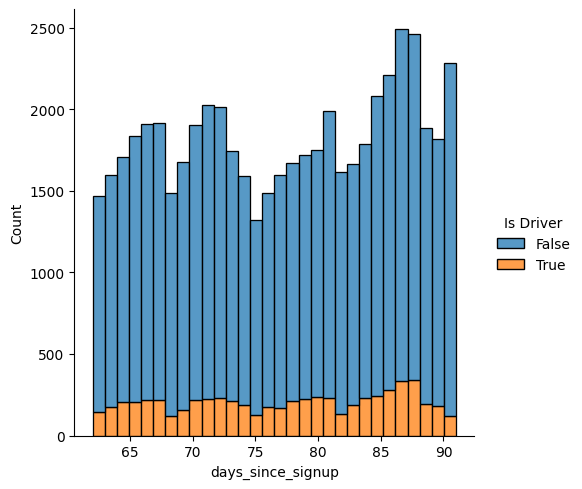

In [5]:
sns.displot(df, x = 'days_since_signup', hue = 'Is Driver', bins = 30,  multiple = 'stack')
plt.show()

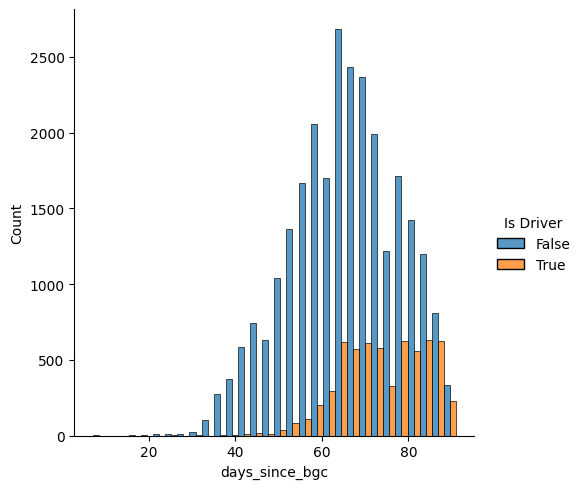

In [6]:
sns.displot(df, x = 'days_since_bgc', hue = 'Is Driver', bins = 30,  multiple = 'dodge')
plt.show()

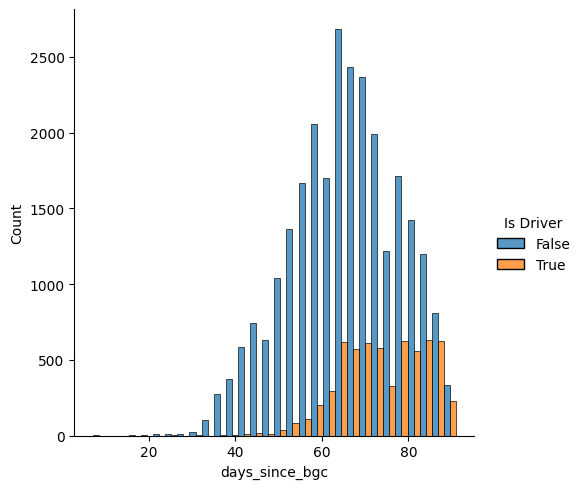

In [7]:
sns.displot(df, x = 'days_since_bgc', hue = 'Is Driver', bins = 30,  multiple = 'dodge')
plt.show()

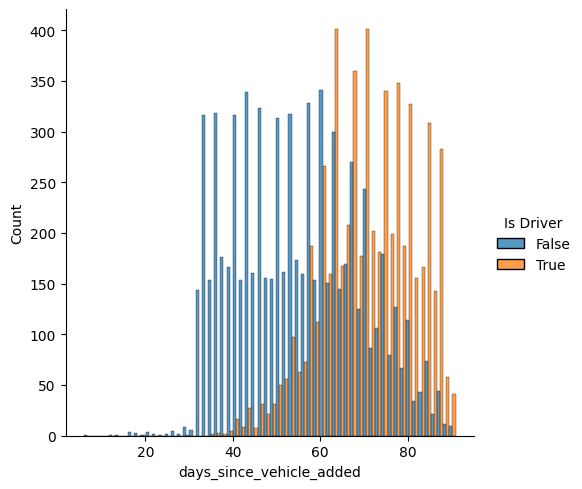

In [8]:
sns.displot(df, x = 'days_since_vehicle_added', hue = 'Is Driver', bins = 60,  multiple = 'dodge')
plt.show()

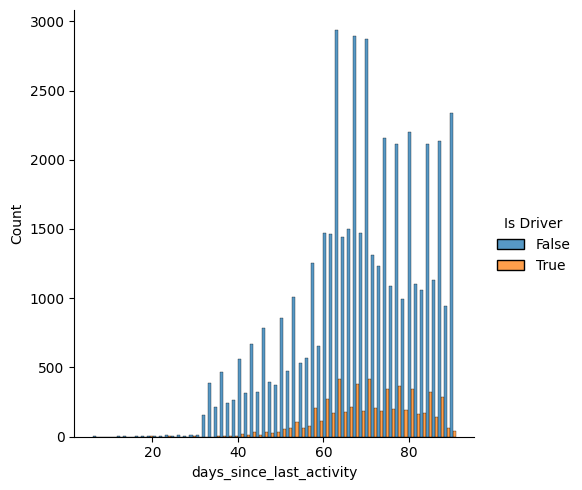

In [9]:
sns.displot(df, x = 'days_since_last_activity', hue = 'Is Driver', bins = 60,  multiple = 'dodge')
plt.show()

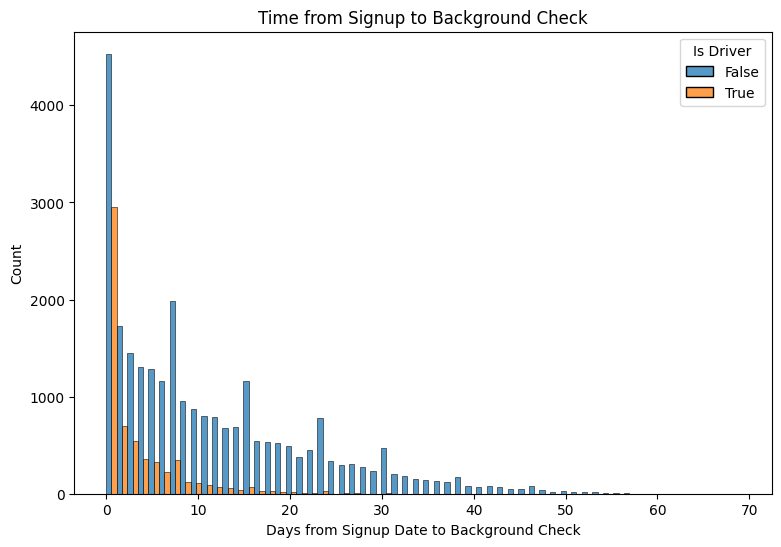

In [42]:
fig, ax = plt.subplots(figsize = (9, 6))
sns.histplot(df, x = 'signup_to_bgc', bins = 60,  hue = 'Is Driver', multiple = 'dodge', ax = ax)
ax.set_title('Time from Signup to Background Check')
ax.set_xlabel('Days from Signup Date to Background Check')
ax.set_ylabel('Count')
plt.show()

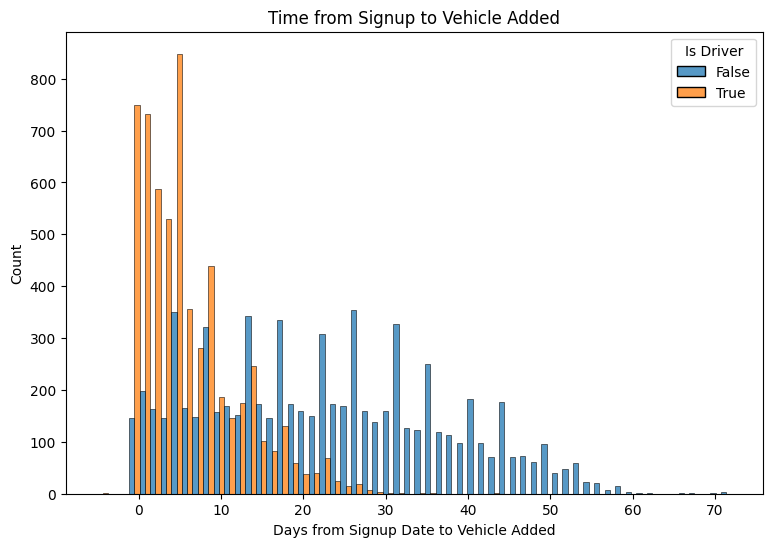

In [43]:
fig, ax = plt.subplots(figsize = (9, 6))
sns.histplot(df, x = 'signup_to_vehicle_added', bins = 60,  hue = 'Is Driver', multiple = 'dodge', ax = ax)
ax.set_title('Time from Signup to Vehicle Added')
ax.set_xlabel('Days from Signup Date to Vehicle Added')
ax.set_ylabel('Count')
plt.show()

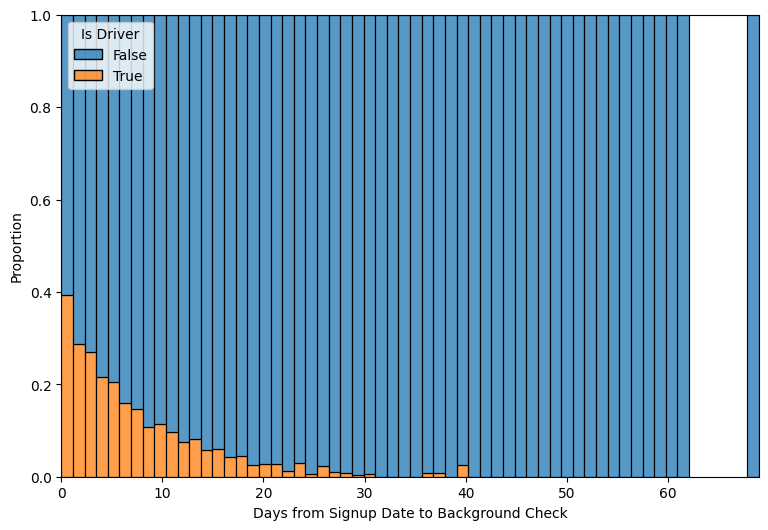

In [11]:
fig, ax = plt.subplots(figsize = (9, 6))
sns.histplot(df, x = 'signup_to_bgc', bins = 60,  hue = 'Is Driver', multiple = 'fill', ax = ax)
ax.set_xlabel('Days from Signup Date to Background Check')
ax.set_ylabel('Proportion')
plt.show()

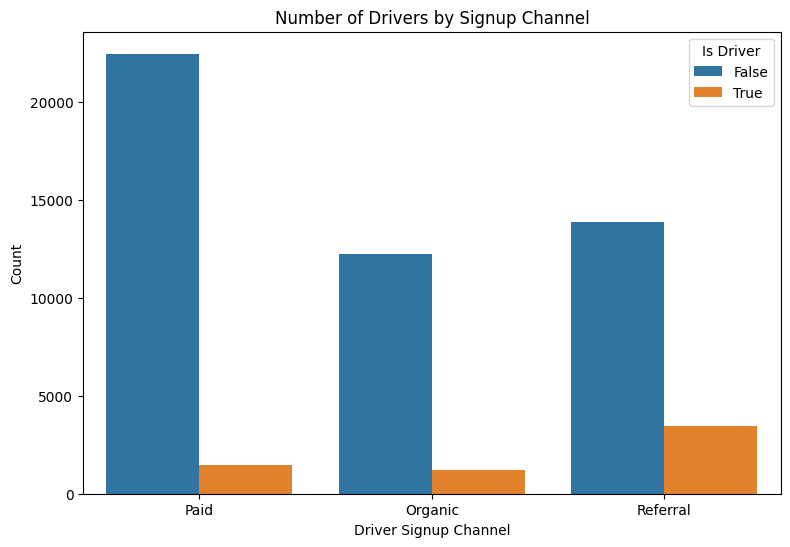

In [41]:
fig, ax = plt.subplots(figsize = (9, 6))
sns.countplot(df, x = 'signup_channel',  hue = 'Is Driver', ax = ax)
ax.set_xlabel('Driver Signup Channel')
ax.set_ylabel('Count')
ax.set_title('Number of Drivers by Signup Channel')
plt.show()

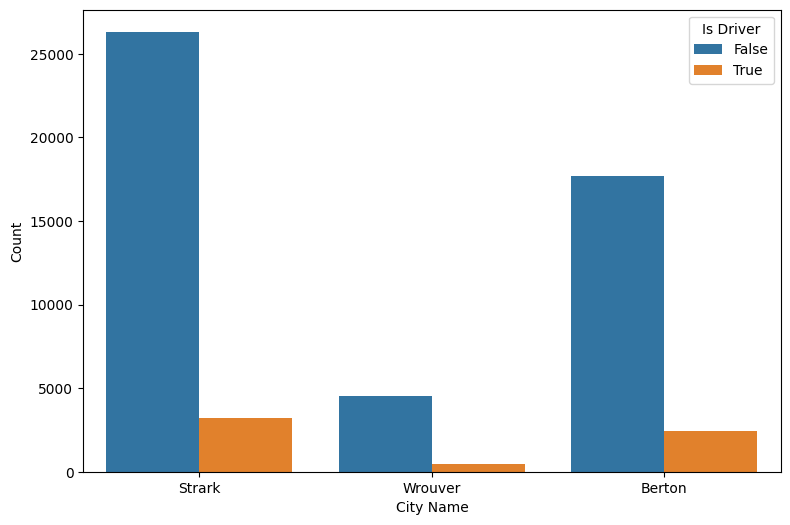

In [13]:
fig, ax = plt.subplots(figsize = (9, 6))
sns.countplot(df, x = 'city_name',  hue = 'Is Driver', ax = ax)
ax.set_xlabel('City Name')
ax.set_ylabel('Count')
plt.show()

In [14]:
df[['city_name', 'Is Driver']].value_counts(normalize = True).reset_index().sort_values(by = 'city_name')

,city_name,Is Driver,proportion
1,Berton,False,0.323330
4,Berton,True,0.044568
0,Strark,False,0.481301
3,Strark,True,0.059234
2,Wrouver,False,0.083137
5,Wrouver,True,0.008431


In [15]:
print(f'Berton: {0.044568/(0.044568+0.323330)}')
print(f'Strark: {0.059234/(0.481301+0.059234)}')
print(f'Wrouver: {0.008431/(0.083137+0.008431)}')

Berton: 0.12114227313005237
Strark: 0.10958402323623818
Wrouver: 0.0920736501834702


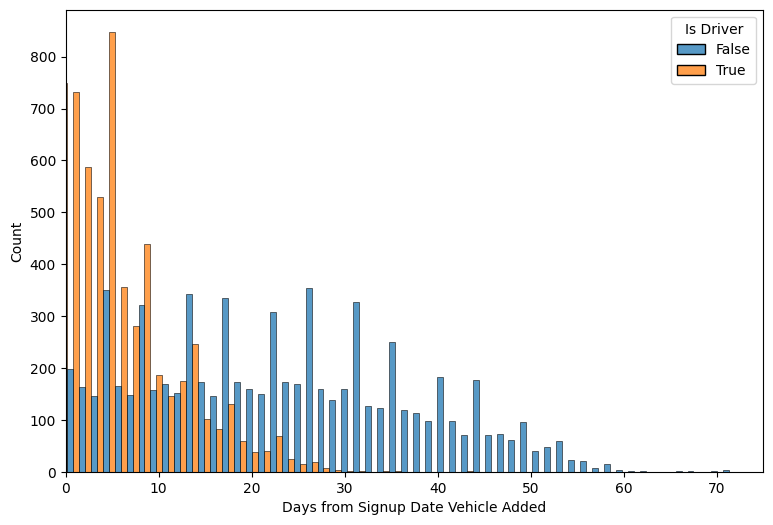

In [16]:
fig, ax = plt.subplots(figsize = (9, 6))
sns.histplot(df, x = 'signup_to_vehicle_added', bins = 60,  hue = 'Is Driver', multiple = 'dodge', ax = ax)
ax.set_xlabel('Days from Signup Date Vehicle Added')
ax.set_ylabel('Count')
ax.set_xlim(0, 75)
plt.show()

In [17]:
# dropoff of each stage
print(f'Signup Total: {df['signup_date'].count()}')
print(f'No Background Check {df['bgc_date'].isnull().sum()}')
print(f'No Vehicle Added: {df['vehicle_added_date'].isnull().sum()}')
print(f'No Ride Given: {df['first_completed_date'].isnull().sum()}')

Signup Total: 54681
No Background Check 21785
No Vehicle Added: 41547
No Ride Given: 48544


In [47]:
# dropoff of each stage
print(f'Signup Total: {df['signup_date'].count()}')
print(f'After Background Check {df['bgc_date'].notnull().sum()}')
print(f'After Vehicle Addition: {df['vehicle_added_date'].notnull().sum()}')
print(f'Total Drivers: {df['first_completed_date'].notnull().sum()}')

# funnel plot?
stages = ['Signups', 'BGC', 'Vehicle Added', 'First Ride']
values = [df['signup_date'].count(), df['bgc_date'].notnull().sum(), df['vehicle_added_date'].notnull().sum(), df['first_completed_date'].notnull().sum()]

values = values[::-1]
stages = stages[::-1]

Signup Total: 54681
After Background Check 32896
After Vehicle Addition: 13134
Total Drivers: 6137


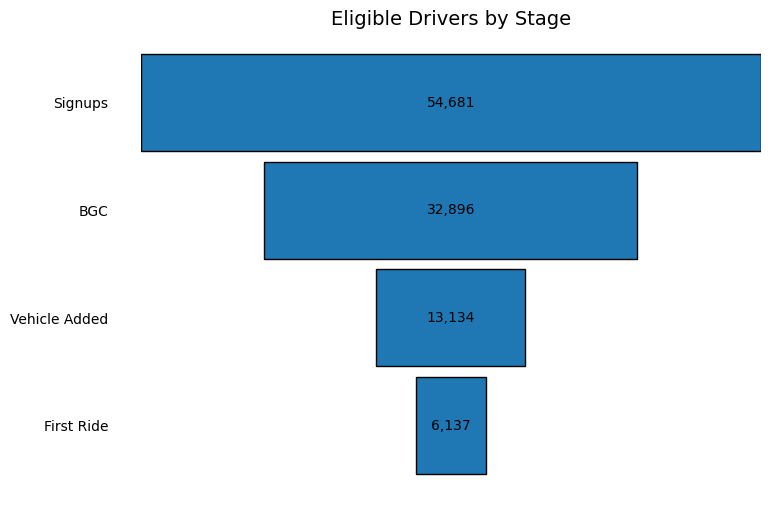

In [54]:
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = range(len(stages)) # Reverse order for top-to-bottom funnel

for i, (stage, value) in enumerate(zip(stages, values)):
    ax.barh(y_pos[i], value, left=(max(values) - value) / 2, height=0.9, color='#1f77b4', edgecolor='black')
    ax.text(max(values)/2, y_pos[i], f'{value:,}', ha='center', va='center', fontsize=10)
ax.set_yticks(y_pos, stages)
#ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_xlim(0, max(values))
ax.set_title('Eligible Drivers by Stage', fontsize=14)
ax.tick_params(right=False, left=False, axis='y', length=20)
plt.show()

In [58]:
df[df['vehicle_year'] >= 1900]['vehicle_year'].max()

np.float64(2017.0)

In [59]:
2017 - 1995

22

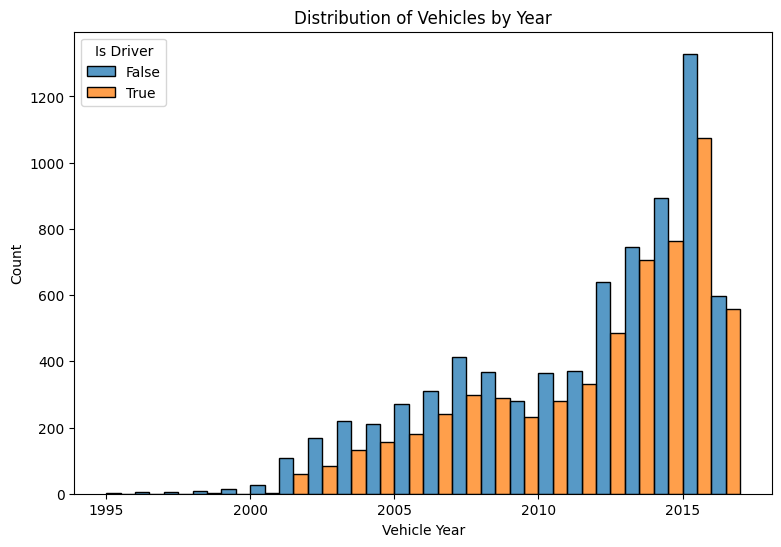

In [65]:
fig, ax = plt.subplots(figsize = (9, 6))
sns.histplot(df[df['vehicle_year'] >= 1900], x = 'vehicle_year', bins = 22,  hue = 'Is Driver', multiple = 'dodge', ax = ax)
ax.set_xlabel('Vehicle Year')
ax.set_ylabel('Count')
ax.set_title('Distribution of Vehicles by Year')
plt.show()